# 📚 Book Dataset — Complete Preprocessing Pipeline

**Source:** `data/raw/book_dataset.csv`  
**Output:** `data/processed/books_processed.csv`  
**Scope:** First 10,000 rows of raw data

---

### Pipeline Steps
1. Load & Inspect Data
2. Remove Duplicates
3. Handle Missing Values
4. Type Casting & Validation
5. Outlier Detection & Removal
6. Feature Engineering
7. Encoding Categorical Variables
8. Normalization
9. Save Processed Data

## 0. Setup & Imports

In [229]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os

from sklearn.preprocessing import LabelEncoder, MinMaxScaler

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 60)
pd.set_option('display.float_format', '{:.2f}'.format)

%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 11

# ── Paths ──────────────────────────────────────────────
RAW_PATH       = r'../data/raw/book_dataset.csv'
PROCESSED_DIR  = r'../data/processed'
OUTPUT_PATH    = os.path.join(PROCESSED_DIR, 'books_processed.csv')
NROWS          = 10_000   # process first 10,000 rows only

os.makedirs(PROCESSED_DIR, exist_ok=True)
print('✅ Setup complete')

✅ Setup complete


---
## Step 1 — Load & Inspect Data

In [230]:
df_raw = pd.read_csv(
    RAW_PATH,
    nrows=NROWS,
    encoding='utf-8',
    low_memory=False
)

df = df_raw.copy()

print(f'Shape: {df.shape}')
print(f'Rows: {df.shape[0]:,}  |  Columns: {df.shape[1]}')
df.head(3)

Shape: (10000, 26)
Rows: 10,000  |  Columns: 26


,id,name,price,list_price,discount_rate,rating_average,review_count,all_time_quantity_sold,authors,publisher_vn,manufacturer,isbn13,book_cover,number_of_page,publication_date,current_seller_name,inventory_status,stock,has_freeship,is_authentic,has_return_policy,cat_level_1,cat_level_2,cat_level_3,cat_level_4,cat_level_5
0,52789367,Sách Nhà Giả Kim (Tái Bản),78000,95000,18,5.00,6076,39825,Paulo Coelho,Nhã Nam,Nhà Xuất Bản Hà Nội,NaN,Bìa mềm,228.00,2020-04-01,Tiki Trading,available,1000.00,False,True,True,nha-sach-tiki,sach-truyen-tieng-viet,sach-van-hoc,tac-pham-kinh-dien,tac-pham-kinh-dien-nuoc-ngoai
1,22881852,English Grammar in Use Book w Ans,207100,218000,5,5.00,2625,12779,Raymond Murphy,Cambridge University,CAMBRIDGE UNIVERSITY,9781108430425,Bìa mềm,NaN,2017-01-01,Nhà sách Fahasa,available,1000.00,True,True,True,nha-sach-tiki,sach-tieng-anh,education-teaching,grammar-vocabulary-skills,NaN
2,750578,Sách Khi Hơi Thở Hóa Thinh Không,78400,109000,28,4.70,2305,62497,Paul Kalanithi,Omega Plus,Nhà Xuất Bản Dân Trí,NaN,Bìa mềm,236.00,2017-07-26,Tiki Trading,available,1000.00,False,True,True,nha-sach-tiki,sach-truyen-tieng-viet,sach-van-hoc,tieu-su-hoi-ky,NaN


=== Column dtypes ===
id                          int64
name                       object
price                       int64
list_price                  int64
discount_rate               int64
rating_average            float64
review_count                int64
all_time_quantity_sold      int64
authors                    object
publisher_vn               object
manufacturer               object
isbn13                     object
book_cover                 object
number_of_page            float64
publication_date           object
current_seller_name        object
inventory_status           object
stock                     float64
has_freeship                 bool
is_authentic                 bool
has_return_policy            bool
cat_level_1                object
cat_level_2                object
cat_level_3                object
cat_level_4                object
cat_level_5                object
dtype: object

=== Missing Values ===
                     missing_count  missing_%
number_of_

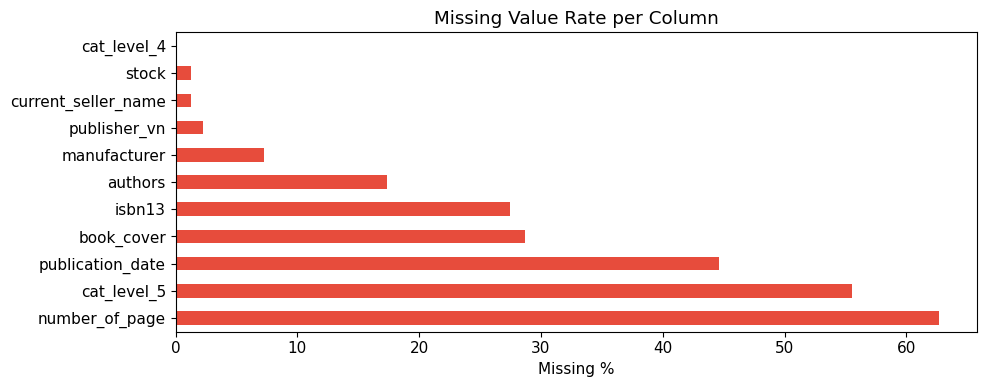

In [231]:
# Data types overview
print('=== Column dtypes ===')
print(df.dtypes)
print()

# Missing value summary
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'missing_count': missing, 'missing_%': missing_pct})
missing_df = missing_df[missing_df['missing_count'] > 0].sort_values('missing_%', ascending=False)

print('=== Missing Values ===')
print(missing_df)

# Plot missing values
if not missing_df.empty:
    fig, ax = plt.subplots(figsize=(10, 4))
    missing_df['missing_%'].plot(kind='barh', ax=ax, color='#E74C3C')
    ax.set_xlabel('Missing %')
    ax.set_title('Missing Value Rate per Column')
    plt.tight_layout()
    plt.show()

In [232]:
# Basic descriptive statistics for numerical columns
num_cols_raw = ['price', 'list_price', 'discount_rate', 'rating_average',
                'review_count', 'all_time_quantity_sold', 'number_of_page']
df[num_cols_raw].describe().T

,count,mean,std,min,25%,50%,75%,max
price,10000.00,249527.81,197427.48,13000.00,130000.00,207500.00,313712.50,3471300.00
list_price,10000.00,266235.01,209119.44,15000.00,145000.00,219000.00,330000.00,3868000.00
discount_rate,10000.00,6.51,9.69,0.00,0.00,5.00,5.00,83.00
rating_average,10000.00,2.29,2.43,0.00,0.00,0.00,5.00,5.00
review_count,10000.00,7.66,80.27,0.00,0.00,0.00,2.00,6076.00
all_time_quantity_sold,10000.00,63.42,816.81,0.00,0.00,2.00,17.00,62497.00
number_of_page,3733.00,322.39,319.85,0.00,150.00,279.00,402.00,10000.00


---
## Step 2 — Remove Duplicates

In [233]:
before = len(df)

# 2a. Exact duplicate rows
n_exact = df.duplicated().sum()
df = df.drop_duplicates()
print(f'Exact duplicate rows removed : {n_exact}')

# 2b. Duplicate by product ID
n_id = df.duplicated(subset=['id']).sum()
df = df.drop_duplicates(subset=['id'], keep='first')
print(f'Duplicate IDs removed        : {n_id}')

# 2c. Same book (name + authors) — keep the one with most reviews
df = df.sort_values('review_count', ascending=False)
n_book = df.duplicated(subset=['name', 'authors'], keep='first').sum()
df = df.drop_duplicates(subset=['name', 'authors'], keep='first')
print(f'Duplicate (name+authors) removed: {n_book}')

print(f'\nRows: {before:,} → {len(df):,}  (removed {before - len(df):,})')

Exact duplicate rows removed : 0
Duplicate IDs removed        : 0
Duplicate (name+authors) removed: 69

Rows: 10,000 → 9,931  (removed 69)


---
## Step 3 — Handle Missing Values

In [234]:
# ── 3a. Drop columns with minimal analytical value ─────
DROP_COLS = [
    'cat_level_1',   # constant value: 'nha-sach-tiki'
    'cat_level_5',   # >80% empty
    'isbn13',        # mostly missing, not used in analysis
    'stock',         # always 1000 when available, redundant with inventory_status
]

df = df.drop(columns=[c for c in DROP_COLS if c in df.columns])
print(f'Dropped columns: {DROP_COLS}')
print(f'Remaining columns ({len(df.columns)}): {list(df.columns)}')

Dropped columns: ['cat_level_1', 'cat_level_5', 'isbn13', 'stock']
Remaining columns (22): ['id', 'name', 'price', 'list_price', 'discount_rate', 'rating_average', 'review_count', 'all_time_quantity_sold', 'authors', 'publisher_vn', 'manufacturer', 'book_cover', 'number_of_page', 'publication_date', 'current_seller_name', 'inventory_status', 'has_freeship', 'is_authentic', 'has_return_policy', 'cat_level_2', 'cat_level_3', 'cat_level_4']


In [235]:
# ── 3b. Numeric columns ───────────────────────────────

# number_of_page: impute with median per cat_level_3
df['number_of_page'] = pd.to_numeric(df['number_of_page'], errors='coerce')
cat3_page_median = df.groupby('cat_level_3')['number_of_page'].transform('median')
global_page_median = df['number_of_page'].median()
df['number_of_page'] = df['number_of_page'].fillna(cat3_page_median).fillna(global_page_median)
print(f'number_of_page — remaining NaN: {df["number_of_page"].isna().sum()}')

# review_count, all_time_quantity_sold: fill 0 if missing
df['review_count'] = pd.to_numeric(df['review_count'], errors='coerce').fillna(0)
df['all_time_quantity_sold'] = pd.to_numeric(df['all_time_quantity_sold'], errors='coerce').fillna(0)

number_of_page — remaining NaN: 0


In [236]:
# ── 3c. Text / Categorical columns ───────────────────

df['authors']              = df['authors'].fillna('Unknown Author')
df['publisher_vn']         = df['publisher_vn'].fillna('Unknown Publisher')
df['manufacturer']         = df['manufacturer'].fillna('Unknown Manufacturer')
df['book_cover']           = df['book_cover'].fillna('Unknown')
df['current_seller_name']  = df['current_seller_name'].fillna('Unknown Seller')
df['cat_level_3']          = df['cat_level_3'].fillna('other')
df['cat_level_4']          = df['cat_level_4'].fillna('other')

print('Text columns filled ✅')

# Final missing value check
still_missing = df.isnull().sum()
still_missing = still_missing[still_missing > 0]
print(f'\nRemaining missing values:')
print(still_missing if not still_missing.empty else '  None ✅')

Text columns filled ✅

Remaining missing values:
publication_date    4420
dtype: int64


---
## Step 4 — Type Casting & Validation

In [237]:
# ── Numeric ──────────────────────────────────────────
df['id']                   = pd.to_numeric(df['id'], errors='coerce')
df['price']                = pd.to_numeric(df['price'], errors='coerce')
df['list_price']           = pd.to_numeric(df['list_price'], errors='coerce')
df['discount_rate']        = pd.to_numeric(df['discount_rate'], errors='coerce')
df['rating_average']       = pd.to_numeric(df['rating_average'], errors='coerce')
df['review_count']         = df['review_count'].astype(int)
df['all_time_quantity_sold'] = df['all_time_quantity_sold'].astype(int)
df['number_of_page']       = df['number_of_page'].astype(int)

# ── Datetime ─────────────────────────────────────────
df['publication_date'] = pd.to_datetime(df['publication_date'], errors='coerce')

# ── Boolean ──────────────────────────────────────────
bool_map = {'True': True, 'False': False, True: True, False: False}
for col in ['has_freeship', 'is_authentic', 'has_return_policy']:
    df[col] = df[col].map(bool_map).fillna(False).astype(bool)

# ── Range Validation ─────────────────────────────────
before = len(df)
df = df[df['price'] > 0]
df = df[df['list_price'] > 0]
df = df[df['discount_rate'].between(0, 100)]
df = df[df['rating_average'].between(0, 5.0)]

print(f'Rows after validation: {before:,} → {len(df):,} (removed {before - len(df):,} invalid rows)')
print()
print(df.dtypes)

Rows after validation: 9,931 → 9,931 (removed 0 invalid rows)

id                                 int64
name                              object
price                              int64
list_price                         int64
discount_rate                      int64
rating_average                   float64
review_count                       int64
all_time_quantity_sold             int64
authors                           object
publisher_vn                      object
manufacturer                      object
book_cover                        object
number_of_page                     int64
publication_date          datetime64[ns]
current_seller_name               object
inventory_status                  object
has_freeship                        bool
is_authentic                        bool
has_return_policy                   bool
cat_level_2                       object
cat_level_3                       object
cat_level_4                       object
dtype: object


---
## Step 6 — Feature Engineering

In [238]:
CURRENT_YEAR = 2026

# ── Time features ─────────────────────────────────────
df['pub_year']   = df['publication_date'].dt.year.fillna(0).astype(int)
df['pub_month']  = df['publication_date'].dt.month.fillna(0).astype(int)
df['book_age']   = (CURRENT_YEAR - df['pub_year']).clip(lower=0)

# ── Price features ────────────────────────────────────
df['saved_amount']   = df['list_price'] - df['price']          # VND saved
df['is_discounted']  = (df['discount_rate'] > 0).astype(int)
df['price_per_page'] = (df['price'] / df['number_of_page'].replace(0, np.nan)).round(2)
df['price_per_page'] = df['price_per_page'].fillna(df['price_per_page'].median())

# ── Engagement features ──────────────────────────────
df['log_review_count']   = np.log1p(df['review_count'])
df['log_qty_sold']       = np.log1p(df['all_time_quantity_sold'])
df['popularity_score']   = (df['rating_average'] * np.log1p(df['review_count'])).round(4)

# ── Text-derived features ────────────────────────────
df['name_length']        = df['name'].str.len()
df['has_multi_authors']  = df['authors'].str.contains(',', na=False).astype(int)
df['is_hardcover']       = df['book_cover'].str.contains('cứng|hard', case=False, na=False).astype(int)
df['is_series']          = df['name'].str.contains(r'[Tt][ậa]p\s*\d|[Vv]ol', regex=True, na=False).astype(int)

# ── Boolean flags ─────────────────────────────────────
df['is_available']     = (df['inventory_status'] == 'available').astype(int)

new_features = [
    'pub_year','pub_month','book_age','saved_amount','is_discounted',
    'price_per_page','log_review_count','log_qty_sold','popularity_score',
    'name_length','has_multi_authors','is_hardcover','is_series','is_available'
]
print(f'New features created ({len(new_features)}): {new_features}')
df[new_features].describe().T

New features created (14): ['pub_year', 'pub_month', 'book_age', 'saved_amount', 'is_discounted', 'price_per_page', 'log_review_count', 'log_qty_sold', 'popularity_score', 'name_length', 'has_multi_authors', 'is_hardcover', 'is_series', 'is_available']


,count,mean,std,min,25%,50%,75%,max
pub_year,9931.00,1121.26,1004.22,0.00,0.00,2015.00,2023.00,2026.00
pub_month,9931.00,4.79,5.19,0.00,0.00,2.00,12.00,12.00
book_age,9931.00,904.74,1004.22,0.00,3.00,11.00,2026.00,2026.00
saved_amount,9931.00,16734.37,36601.30,0.00,0.00,8700.00,18500.00,1000000.00
is_discounted,9931.00,0.65,0.48,0.00,0.00,1.00,1.00,1.00
price_per_page,9931.00,1991.68,2736.27,29.31,500.00,1340.03,2562.50,48000.00
log_review_count,9931.00,0.76,1.11,0.00,0.00,0.00,1.10,8.71
log_qty_sold,9931.00,1.69,1.86,0.00,0.00,1.10,2.89,11.04
popularity_score,9931.00,3.66,5.42,0.00,0.00,0.00,5.49,43.56
name_length,9931.00,51.72,26.40,3.00,32.00,47.00,67.00,231.00


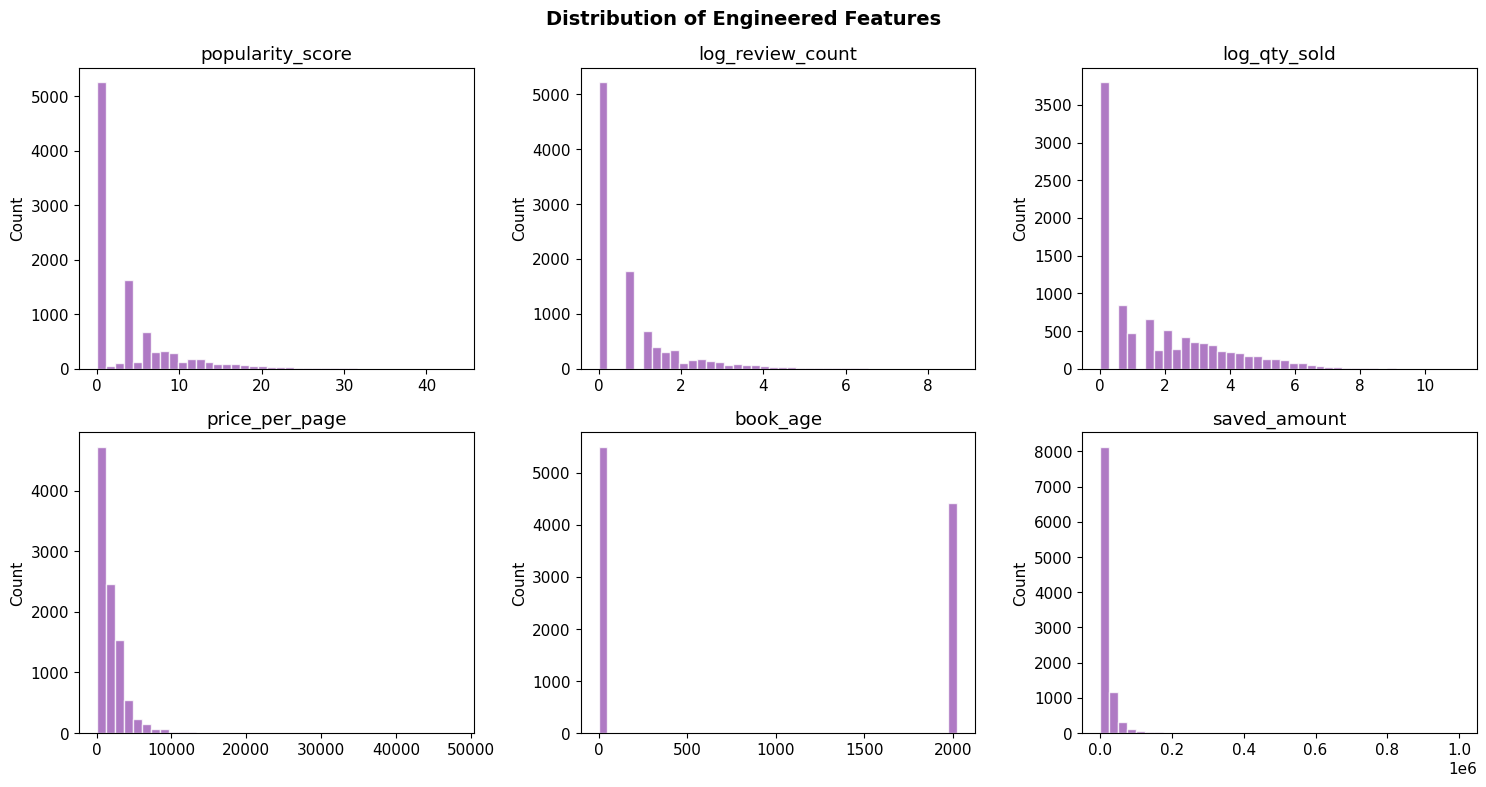

In [239]:
# Distribution plots for key engineered features
plot_cols = ['popularity_score', 'log_review_count', 'log_qty_sold',
             'price_per_page', 'book_age', 'saved_amount']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.flatten(), plot_cols):
    ax.hist(df[col].dropna(), bins=40, color='#9B59B6', edgecolor='white', alpha=0.8)
    ax.set_title(col)
    ax.set_ylabel('Count')
plt.suptitle('Distribution of Engineered Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Step 7 — Encoding Categorical Variables

In [240]:
# ── 7a. book_cover — Label Encoding ──────────────────
le = LabelEncoder()
df['book_cover_enc'] = le.fit_transform(df['book_cover'].astype(str))
mapping = dict(zip(le.classes_, le.transform(le.classes_)))
print('book_cover label encoding:')
for k, v in sorted(mapping.items(), key=lambda x: x[1]):
    print(f'  {k:25s} → {v}')

book_cover label encoding:
  Board book                → 0
  Box                       → 1
  Boxset                    → 2
  Bìa Da                    → 3
  Bìa Da Công Nghiệp Microfiber → 4
  Bìa cứng                  → 5
  Bìa cứng áo ôm            → 6
  Bìa gập                   → 7
  Bìa mềm                   → 8
  Bìa mềm tay gấp           → 9
  Bìa mềm, cán sần, phủ nhũ → 10
  Bìa mềm, rời              → 11
  Bìa rời                   → 12
  Bìa vải                   → 13
  Cloth book                → 14
  Clothbound hardback       → 15
  Clothbound hardback with slipcase → 16
  Hard cover                → 17
  Hardback                  → 18
  Hardback + jacket         → 19
  Hardcover                 → 20
  Kit or Box Set            → 21
  Leatherbound Harback      → 22
  Mass market paperback     → 23
  Mixed media product       → 24
  Offer 3 books             → 25
  Offer 4 books             → 26
  Padded hardback           → 27
  Paperback                 → 28
  Trade paperb

In [241]:
# ── 7b. inventory_status — Label Encoding ────────────
df['inventory_status_enc'] = (df['inventory_status'] == 'available').astype(int)
print('inventory_status encoded: available=1, out_of_stock=0')

# ── 7c. cat_level_2 — One-Hot Encoding ───────────────
cat2_dummies = pd.get_dummies(df['cat_level_2'], prefix='cat2', dtype=int)
df = pd.concat([df, cat2_dummies], axis=1)
print(f'\ncat_level_2 one-hot columns: {list(cat2_dummies.columns)}')

# ── 7d. cat_level_3 — Target Encoding (mean rating) ──
cat3_mean = df.groupby('cat_level_3')['rating_average'].mean()
df['cat3_rating_enc'] = df['cat_level_3'].map(cat3_mean).round(4)
print(f'\ncat3_rating_enc sample:')
print(df[['cat_level_3', 'cat3_rating_enc']].drop_duplicates().head(10))

inventory_status encoded: available=1, out_of_stock=0

cat_level_2 one-hot columns: ['cat2_sach-tieng-anh', 'cat2_sach-truyen-tieng-viet']

cat3_rating_enc sample:
                          cat_level_3  cat3_rating_enc
0                        sach-van-hoc             4.82
1                  education-teaching             1.52
16                         dictionary             1.82
57   history-politics-social-sciences             4.86
76                biographies-memoirs             4.71
91                 fiction-literature             2.30
181                         self-help             4.67
195                         reference             4.59
251                business-economics             4.67
449                    children-books             0.59


---
## Step 8 — Normalization (Min-Max Scaling)

In [242]:
SCALE_COLS = [
    'price', 'list_price', 'saved_amount', 'discount_rate',
    'rating_average', 'number_of_page', 'name_length',
    'price_per_page', 'popularity_score', 'book_age'
]

scaler = MinMaxScaler()
scaled_colnames = [c + '_scaled' for c in SCALE_COLS]
df[scaled_colnames] = scaler.fit_transform(df[SCALE_COLS])

print(f'Scaled {len(SCALE_COLS)} columns → suffix "_scaled"')
df[scaled_colnames].describe().T[['min','mean','max']]

Scaled 10 columns → suffix "_scaled"


,min,mean,max
price_scaled,0.00,0.07,1.00
list_price_scaled,0.00,0.07,1.00
saved_amount_scaled,0.00,0.02,1.00
discount_rate_scaled,0.00,0.08,1.00
rating_average_scaled,0.00,0.46,1.00
number_of_page_scaled,0.00,0.02,1.00
name_length_scaled,0.00,0.21,1.00
price_per_page_scaled,0.00,0.04,1.00
popularity_score_scaled,0.00,0.08,1.00
book_age_scaled,0.00,0.45,1.00


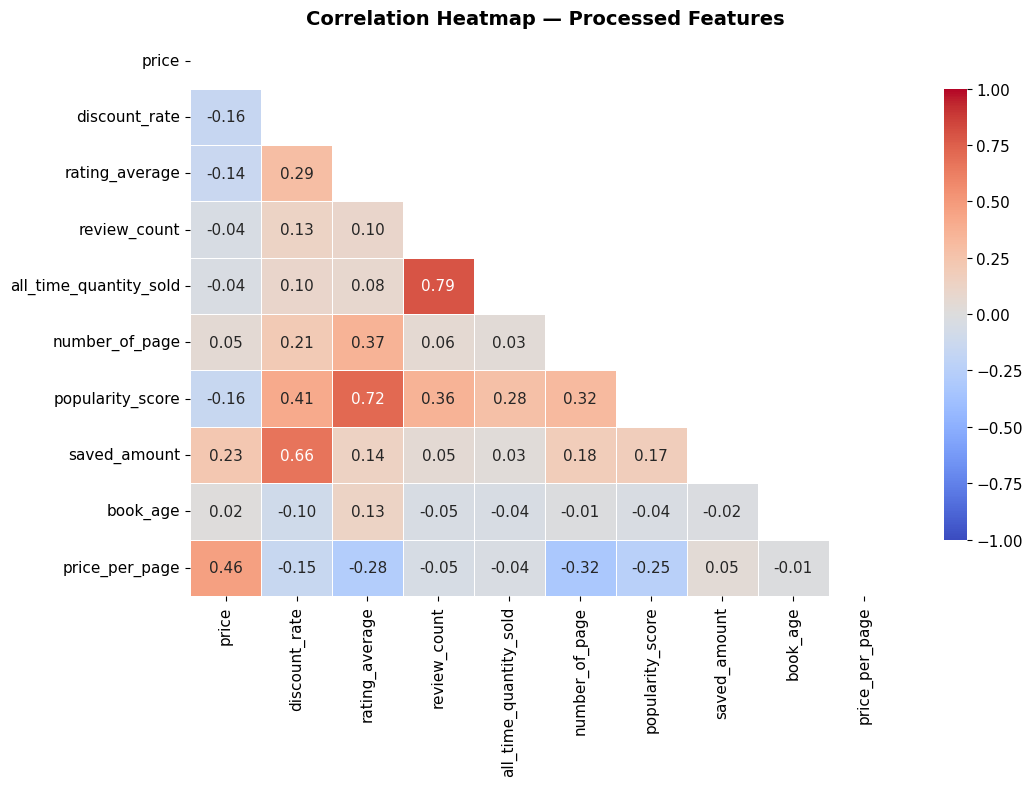

In [243]:
# Correlation heatmap on key numeric features
corr_cols = ['price', 'discount_rate', 'rating_average', 'review_count',
             'all_time_quantity_sold', 'number_of_page', 'popularity_score',
             'saved_amount', 'book_age', 'price_per_page']

corr = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(11, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
    vmin=-1, vmax=1, center=0, linewidths=0.5,
    cbar_kws={'shrink': 0.8}, ax=ax
)
ax.set_title('Correlation Heatmap — Processed Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Step 9 — Final Summary & Save

In [244]:
# ── Final summary ─────────────────────────────────────
print('='*55)
print('            PREPROCESSING SUMMARY')
print('='*55)
print(f'  Raw rows loaded        : {NROWS:,}')
print(f'  Final rows             : {len(df):,}')
print(f'  Rows removed total     : {NROWS - len(df):,}')
print(f'  Final columns          : {df.shape[1]}')
print(f'  Missing values left    : {df.isnull().sum().sum()}')
print('='*55)

# Column categories
print('\nColumn breakdown:')
original_cols   = list(df_raw.columns)
dropped         = [c for c in original_cols if c not in df.columns]
new_cols        = [c for c in df.columns if c not in original_cols]
kept_cols       = [c for c in df.columns if c in original_cols]
print(f'  Kept original : {len(kept_cols)}')
print(f'  Dropped       : {len(dropped)}  → {dropped}')
print(f'  Added new     : {len(new_cols)}')

            PREPROCESSING SUMMARY
  Raw rows loaded        : 10,000
  Final rows             : 9,931
  Rows removed total     : 69
  Final columns          : 51
  Missing values left    : 4420

Column breakdown:
  Kept original : 22
  Dropped       : 4  → ['isbn13', 'stock', 'cat_level_1', 'cat_level_5']
  Added new     : 29


In [245]:
# Column inventory
col_info = []
for col in df.columns:
    col_info.append({
        'column': col,
        'dtype': str(df[col].dtype),
        'non_null': df[col].notna().sum(),
        'unique': df[col].nunique(),
        'is_new': col not in original_cols
    })

col_df = pd.DataFrame(col_info)
print(col_df.to_string(index=False))

                     column          dtype  non_null  unique  is_new
                         id          int64      9931    9931   False
                       name         object      9931    9895   False
                      price          int64      9931    2255   False
                 list_price          int64      9931     992   False
              discount_rate          int64      9931      65   False
             rating_average        float64      9931      26   False
               review_count          int64      9931     200   False
     all_time_quantity_sold          int64      9931     564   False
                    authors         object      9931    2922   False
               publisher_vn         object      9931     551   False
               manufacturer         object      9931     481   False
                 book_cover         object      9931      32   False
             number_of_page          int64      9931     643   False
           publication_date dateti

In [246]:
# ── Save to CSV ───────────────────────────────────────
df.to_csv(OUTPUT_PATH, index=False, encoding='utf-8-sig')

file_size_mb = os.path.getsize(OUTPUT_PATH) / (1024 * 1024)
print(f'✅ Processed data saved to: {OUTPUT_PATH}')
print(f'   Shape  : {df.shape}')
print(f'   Size   : {file_size_mb:.2f} MB')

# Quick peek at the final dataset
df.head(3)

✅ Processed data saved to: ../data/processed\books_processed.csv
   Shape  : (9931, 51)
   Size   : 4.67 MB


,id,name,price,list_price,discount_rate,rating_average,review_count,all_time_quantity_sold,authors,publisher_vn,manufacturer,book_cover,number_of_page,publication_date,current_seller_name,inventory_status,has_freeship,is_authentic,has_return_policy,cat_level_2,cat_level_3,cat_level_4,pub_year,pub_month,book_age,saved_amount,is_discounted,price_per_page,log_review_count,log_qty_sold,popularity_score,name_length,has_multi_authors,is_hardcover,is_series,is_available,book_cover_enc,inventory_status_enc,cat2_sach-tieng-anh,cat2_sach-truyen-tieng-viet,cat3_rating_enc,price_scaled,list_price_scaled,saved_amount_scaled,discount_rate_scaled,rating_average_scaled,number_of_page_scaled,name_length_scaled,price_per_page_scaled,popularity_score_scaled,book_age_scaled
0,52789367,Sách Nhà Giả Kim (Tái Bản),78000,95000,18,5.00,6076,39825,Paulo Coelho,Nhã Nam,Nhà Xuất Bản Hà Nội,Bìa mềm,228,2020-04-01,Tiki Trading,available,False,True,True,sach-truyen-tieng-viet,sach-van-hoc,tac-pham-kinh-dien,2020,4,6,17000,1,342.11,8.71,10.59,43.56,26,0,0,0,1,8,1,0,1,4.82,0.02,0.02,0.02,0.22,1.00,0.02,0.10,0.01,1.00,0.00
1,22881852,English Grammar in Use Book w Ans,207100,218000,5,5.00,2625,12779,Raymond Murphy,Cambridge University,CAMBRIDGE UNIVERSITY,Bìa mềm,128,2017-01-01,Nhà sách Fahasa,available,True,True,True,sach-tieng-anh,education-teaching,grammar-vocabulary-skills,2017,1,9,10900,1,1617.97,7.87,9.46,39.37,33,0,0,0,1,8,1,1,0,1.52,0.06,0.05,0.01,0.06,1.00,0.01,0.13,0.03,0.90,0.00
2,750578,Sách Khi Hơi Thở Hóa Thinh Không,78400,109000,28,4.70,2305,62497,Paul Kalanithi,Omega Plus,Nhà Xuất Bản Dân Trí,Bìa mềm,236,2017-07-26,Tiki Trading,available,False,True,True,sach-truyen-tieng-viet,sach-van-hoc,tieu-su-hoi-ky,2017,7,9,30600,1,332.20,7.74,11.04,36.39,32,0,0,0,1,8,1,0,1,4.82,0.02,0.02,0.03,0.34,0.94,0.02,0.13,0.01,0.84,0.00


---
## 📈 Bonus — Quick EDA on Processed Data

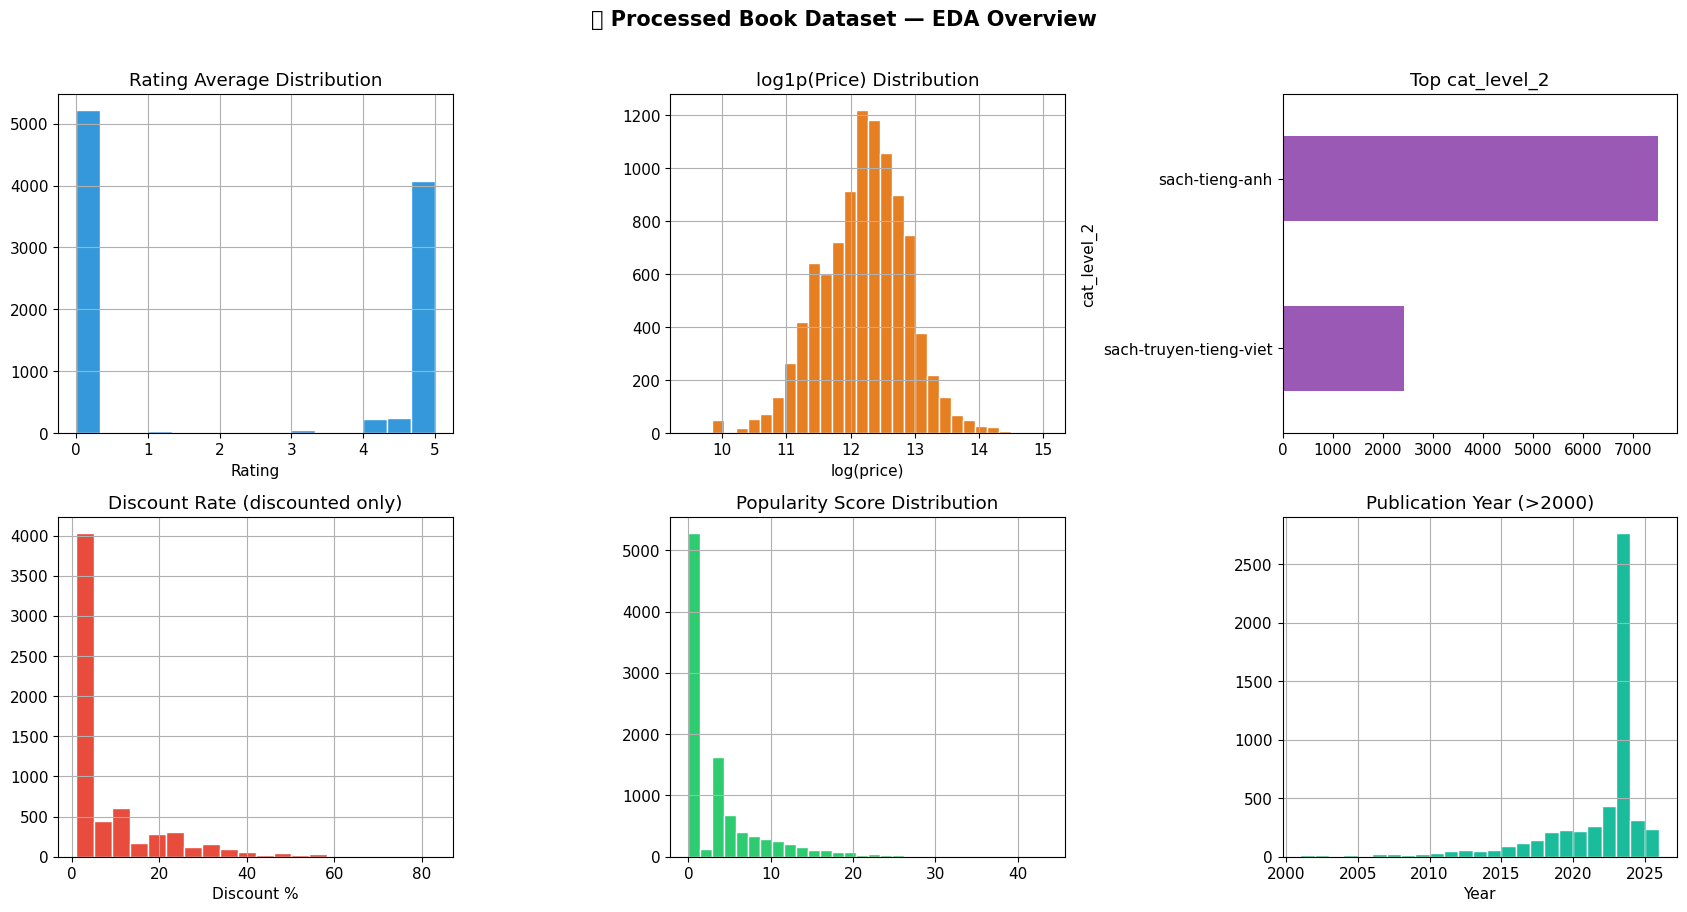


✅ Pipeline complete!


In [247]:
fig, axes = plt.subplots(2, 3, figsize=(17, 9))

# 1. Rating distribution
df['rating_average'].hist(bins=15, ax=axes[0,0], color='#3498DB', edgecolor='white')
axes[0,0].set_title('Rating Average Distribution')
axes[0,0].set_xlabel('Rating')

# 2. Price distribution (log scale)
np.log1p(df['price']).hist(bins=30, ax=axes[0,1], color='#E67E22', edgecolor='white')
axes[0,1].set_title('log1p(Price) Distribution')
axes[0,1].set_xlabel('log(price)')

# 3. Top categories
cat2_counts = df['cat_level_2'].value_counts().head(8)
cat2_counts.plot(kind='barh', ax=axes[0,2], color='#9B59B6')
axes[0,2].set_title('Top cat_level_2')
axes[0,2].invert_yaxis()

# 4. Discount rate distribution
df[df['discount_rate'] > 0]['discount_rate'].hist(
    bins=20, ax=axes[1,0], color='#E74C3C', edgecolor='white')
axes[1,0].set_title('Discount Rate (discounted only)')
axes[1,0].set_xlabel('Discount %')

# 5. Popularity score
df['popularity_score'].hist(bins=30, ax=axes[1,1], color='#2ECC71', edgecolor='white')
axes[1,1].set_title('Popularity Score Distribution')

# 6. Publication year
df[df['pub_year'] > 2000]['pub_year'].hist(
    bins=25, ax=axes[1,2], color='#1ABC9C', edgecolor='white')
axes[1,2].set_title('Publication Year (>2000)')
axes[1,2].set_xlabel('Year')

plt.suptitle('📚 Processed Book Dataset — EDA Overview', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()
print('\n✅ Pipeline complete!')